# Predictive Maintenance for Construction Plant
**Author:** Atul Iwale · **Project 9** of the AEC Fieldwork portfolio (machine-learning upgrade)

**Business question:** which cranes, excavators, pumps, generators and hoists are likely to break down in the next four weeks, so the plant team can inspect and repair them *before* they stop a site?

The first version of this project flagged a fixed pattern in the maintenance log (rating falling 3 → 2 → 1 with three symptoms). That only works after the damage is visible. This notebook uses weekly telematics (vibration, temperature, hydraulic pressure, fault codes, oil analysis) from the same asset register to *predict* breakdowns, and compares a range of machine-learning models, with a focus on **XGBoost vs Support Vector Machine**.

**Contents**
1. Load and audit the data
2. What a breakdown costs
3. Do sensors warn before a breakdown?
4. Label and features (with leakage safeguards)
5. Time-based split
6. Baselines: OEM alarm limits and PM-overdue rule
7. Models: Logistic Regression, KNN, Decision Tree, Random Forest, XGBoost, SVM, Neural Network (MLP)
8. Compare on unseen months
9. XGBoost vs SVM
10. Business value: cost-based alert threshold, breakdowns caught, lead time, savings
11. Explain the model (SHAP)
12. This week's maintenance worklist
13. Export for the web app

In [1]:
import warnings, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, brier_score_loss
import xgboost as xgb, shap
pd.set_option('display.width', 170); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
RS = 42
DATA = '../data/09_Construction_Assets_v2.xlsx'

## 1. Load and audit the data

In [2]:
x = pd.read_excel(DATA, sheet_name=None)
for k, v in x.items(): print(f'{k:24s} {v.shape[0]:>6,} rows x {v.shape[1]} cols')
asset, meta, tel, ev = x['dim_asset'], x['dim_asset_telematics'], x['fact_telemetry_weekly'].copy(), x['fact_maintenance_event'].copy()
tel['week_start'] = pd.to_datetime(tel.week_start); ev['event_date'] = pd.to_datetime(ev.event_date)
ev['week_start'] = ev.event_date - pd.to_timedelta(ev.event_date.dt.weekday, unit='D')
checks = {
  'telematics assets found in dim_asset': meta.asset_id.isin(asset.asset_id).all(),
  'telemetry assets found in dim_asset_telematics': tel.asset_id.isin(meta.asset_id).all(),
  'event assets found in dim_asset_telematics': ev.asset_id.isin(meta.asset_id).all(),
  'unique reading_id / event_id': tel.reading_id.is_unique and ev.event_id.is_unique,
  'one reading per asset per week': not tel.duplicated(['asset_id', 'week_start']).any(),
  'every breakdown week has a Breakdown or Operating row': ev[ev.event_type == 'Breakdown'].merge(tel, on=['asset_id', 'week_start']).shape[0] == (ev.event_type == 'Breakdown').sum(),
}
for k, v in checks.items(): print('OK ' if v else 'FAIL', k)
print('\nMonitored plant:', meta.asset_class.value_counts().to_dict())
print('Not monitored (no telematics):', asset[~asset.asset_id.isin(meta.asset_id)].asset_name.str.replace(r' \d+$', '', regex=True).value_counts().to_dict())
print('Weeks:', tel.week_start.min().date(), 'to', tel.week_start.max().date())
op = tel[tel.status == 'Operating']
print('\nMissing values in operating weeks (%):'); print((op.isna().mean() * 100).round(1)[lambda s: s > 0].to_string())

dim_asset                   100 rows x 5 cols
fact_maintenance_log        600 rows x 6 cols
answer_key                  600 rows x 3 cols
data_dictionary              18 rows x 4 cols
dim_asset_telematics         80 rows x 10 cols
fact_telemetry_weekly     6,270 rows x 15 cols
fact_maintenance_event    1,186 rows x 9 cols
data_dictionary_v2           30 rows x 4 cols
OK  telematics assets found in dim_asset
OK  telemetry assets found in dim_asset_telematics
OK  event assets found in dim_asset_telematics
OK  unique reading_id / event_id
OK  one reading per asset per week
OK  every breakdown week has a Breakdown or Operating row

Monitored plant: {'Tower Crane': 10, 'Crawler Crane': 10, 'Excavator': 10, 'Backhoe Loader': 10, 'Concrete Pump': 10, 'Transit Mixer': 10, 'Diesel Generator': 10, 'Passenger Hoist': 10}
Not monitored (no telematics): {'Bar Cutting Machine': 10, 'Survey Total Station': 10}
Weeks: 2024-10-07 to 2026-09-21

Missing values in operating weeks (%):
project_id         

**Audit notes.** All joins are complete. Missing values have three different causes and are treated differently:
- **Project ID (blank in about 21% of weeks):** the machine was working on another company contract outside the Project 1 portfolio. The city is always known.
- **Telematics dropouts (about 3.7% of operating weeks):** the whole sensor row is blank. Short gaps (up to 2 weeks) are bridged with the last reading; a `sensor_dropout` flag is kept.
- **Hydraulic pressure:** blank by design for tower cranes, hoists and generators, which have no main hydraulic circuit.
- **Oil iron (ppm):** oil is sampled every 4th operating week, so the last lab result is carried forward.

## 2. What a breakdown costs

249 breakdowns on 77 machines in 24 months
Repair cost Rs 8.71 crore + replacement hire Rs 3.40 crore = Rs 12.11 crore
Planned events: 725 preventive services, 70 planned corrective repairs, 142 site transfers


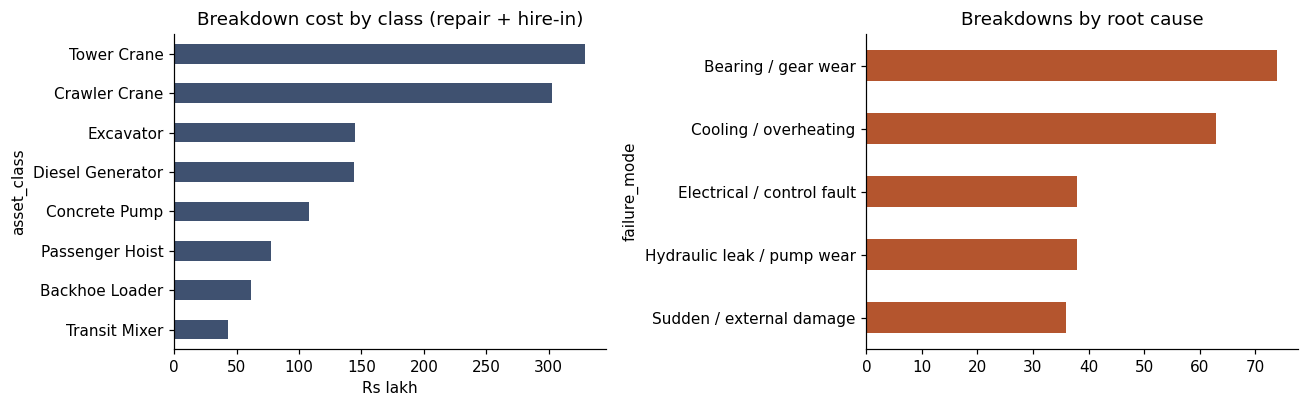

,breakdowns,avg_repair_lakh,avg_downtime_days,avg_total_lakh
asset_class,,,,
Backhoe Loader,29,1.6,8.1,2.1
Concrete Pump,24,2.6,10.0,4.5
Crawler Crane,26,7.4,10.1,11.6
Diesel Generator,57,2.2,8.1,2.5
Excavator,31,3.5,8.6,4.7
Passenger Hoist,30,1.8,8.4,2.6
Tower Crane,29,8.7,9.4,11.4
Transit Mixer,23,1.4,9.0,1.9


In [3]:
bd = ev[ev.event_type == 'Breakdown'].merge(meta[['asset_id', 'asset_class', 'hire_in_rate_inr_per_day']], on='asset_id')
bd['hire_in_cost'] = bd.downtime_days * bd.hire_in_rate_inr_per_day
bd['total_cost'] = bd.cost_inr + bd.hire_in_cost
print(f"{len(bd)} breakdowns on {bd.asset_id.nunique()} machines in {tel.week_start.dt.to_period('M').nunique()} months")
print(f"Repair cost Rs {bd.cost_inr.sum()/1e7:.2f} crore + replacement hire Rs {bd.hire_in_cost.sum()/1e7:.2f} crore = Rs {bd.total_cost.sum()/1e7:.2f} crore")
print(f"Planned events: {(ev.event_type=='Preventive service').sum()} preventive services, {(ev.event_type=='Corrective repair (planned)').sum()} planned corrective repairs, {(ev.event_type=='Transfer').sum()} site transfers")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
bd.groupby('asset_class').total_cost.sum().div(1e5).sort_values().plot.barh(ax=ax[0], color='#3f5170'); ax[0].set_xlabel('Rs lakh'); ax[0].set_title('Breakdown cost by class (repair + hire-in)')
bd.failure_mode.value_counts().sort_values().plot.barh(ax=ax[1], color='#b4552e'); ax[1].set_title('Breakdowns by root cause'); plt.tight_layout(); plt.show()
bd.groupby('asset_class').agg(breakdowns=('event_id', 'size'), avg_repair_lakh=('cost_inr', lambda s: s.mean() / 1e5), avg_downtime_days=('downtime_days', 'mean'), avg_total_lakh=('total_cost', lambda s: s.mean() / 1e5)).round(1)

## 3. Do sensors warn before a breakdown?
If the machine's own readings change in the weeks before a failure, a model can learn it. Each panel lines up every breakdown of one root cause at week 0 and shows the average of the matching sensor.

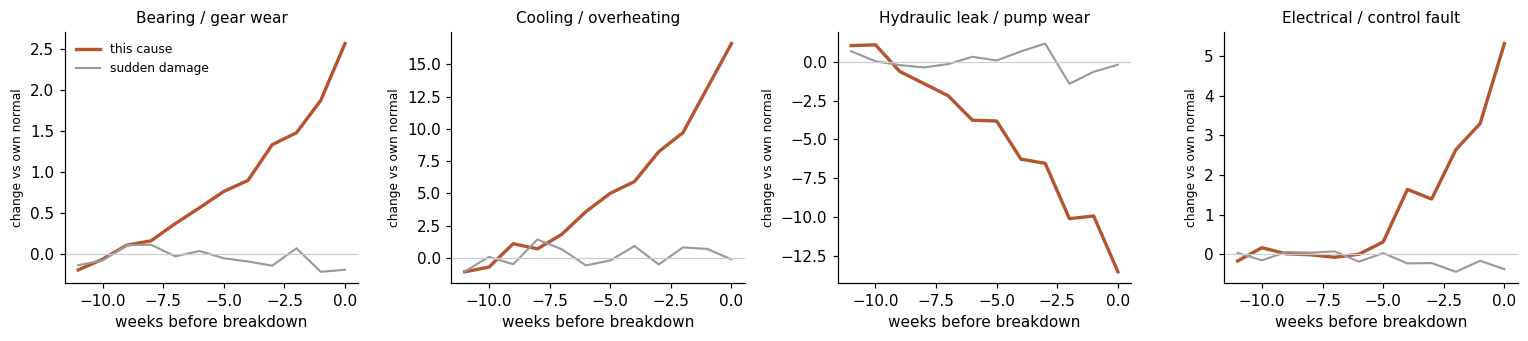

In [4]:
t = tel.sort_values(['asset_id', 'week_start'])
rows = []
for r in bd.itertuples():
    h = t[(t.asset_id == r.asset_id) & (t.week_start <= r.week_start) & (t.week_start > r.week_start - pd.Timedelta(weeks=12)) & (t.status == 'Operating')].copy()
    h['wk'] = -((r.week_start - h.week_start).dt.days // 7); h['mode'] = r.failure_mode
    base = h[h.wk <= -8][['vibration_rms_mm_s', 'operating_temp_c', 'hydraulic_pressure_pct', 'fault_codes']].mean()
    for c in base.index: h[c] = h[c] - base[c]
    rows.append(h)
al = pd.concat(rows)
sig = {'Bearing / gear wear': 'vibration_rms_mm_s', 'Cooling / overheating': 'operating_temp_c', 'Hydraulic leak / pump wear': 'hydraulic_pressure_pct', 'Electrical / control fault': 'fault_codes'}
fig, ax = plt.subplots(1, 4, figsize=(14, 3.2))
for a, (m, c) in zip(ax, sig.items()):
    for mm, col, lw in [(m, '#b4552e', 2.2), ('Sudden / external damage', '#9a9a9a', 1.4)]:
        s = al[al['mode'] == mm].groupby('wk')[c].mean(); a.plot(s.index, s.values, color=col, lw=lw, label='this cause' if mm == m else 'sudden damage')
    a.axhline(0, color='#ccc', lw=.8); a.set_title(m, fontsize=10); a.set_xlabel('weeks before breakdown'); a.set_ylabel('change vs own normal', fontsize=8)
ax[0].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

Each wear-related cause shows a rising (or, for hydraulic pressure, falling) signal over the last 4 to 8 weeks. Maintenance engineers call this the **P-F interval**: the time between a detectable problem (P) and functional failure (F). Sudden external damage (for example an impact or a burst hose from site conditions) shows no warning. No model can predict those, so they cap the achievable recall.

## 4. Label and features
**Label:** `y = 1` if the machine has a breakdown in the **next 4 weeks** (weeks t+1 to t+4). Four weeks is enough time to order parts and plan a repair around the site programme.

**Leakage safeguards:** every feature uses only readings and events up to the end of week t. The machine's 'normal' level is the median of weeks t-16 to t-4, so a developing fault doesn't hide itself in the baseline. Weeks when the machine is broken down or in transit are not scored. The last 4 weeks have no known outcome yet and become the live scoring week.

In [5]:
import numpy as np, pandas as pd
H = 4  # prediction horizon in weeks

def load(path):
    x = pd.read_excel(path, sheet_name=None)
    tel = x['fact_telemetry_weekly'].copy(); ev = x['fact_maintenance_event'].copy(); meta = x['dim_asset_telematics'].copy()
    tel['week_start'] = pd.to_datetime(tel.week_start); ev['event_date'] = pd.to_datetime(ev.event_date)
    ev['week_start'] = ev.event_date - pd.to_timedelta(ev.event_date.dt.weekday, unit='D')
    return x, tel, ev, meta

def slope(s, n):
    """least-squares slope per week over the last n values (NaN-tolerant)"""
    def f(v):
        m = ~np.isnan(v)
        if m.sum() < 3: return np.nan
        t = np.arange(len(v))[m]; y = v[m]; t = t - t.mean()
        return float((t * (y - y.mean())).sum() / (t * t).sum())
    return s.rolling(n, min_periods=3).apply(f, raw=True)

def build(tel, ev, meta):
    t = tel.sort_values(['asset_id', 'week_start']).copy()
    t = t.merge(meta[['asset_id', 'asset_class', 'power_source', 'hydraulic_system', 'year_of_manufacture', 'pm_interval_hours']], on='asset_id')
    bd = ev[ev.event_type == 'Breakdown'][['asset_id', 'week_start', 'failure_mode']].copy()
    # ---- label: a breakdown in the next H weeks (weeks t+1 .. t+H) ----
    bset = bd.groupby('asset_id').week_start.apply(lambda s: np.sort(s.values)).to_dict()
    def nxt(r):
        s = bset.get(r.asset_id)
        if s is None: return pd.NaT
        f = s[s > np.datetime64(r.week_start)]
        return f[0] if len(f) else pd.NaT
    t['next_breakdown'] = [nxt(r) for r in t[['asset_id', 'week_start']].itertuples()]
    t['weeks_to_breakdown'] = (t.next_breakdown - t.week_start).dt.days / 7
    last_week = t.week_start.max()
    t['label_known'] = t.week_start <= last_week - pd.Timedelta(weeks=H)
    t['y'] = (t.weeks_to_breakdown <= H).astype(int)
    # ---- history features, computed on operating weeks only, using past and current data only ----
    op = t[t.status == 'Operating'].copy()
    g = op.groupby('asset_id', group_keys=False)
    for c in ['vibration_rms_mm_s', 'operating_temp_c', 'hydraulic_pressure_pct', 'load_factor_pct', 'fault_codes']:
        op[c + '_f'] = g[c].ffill(limit=2)                                    # bridge short telematics dropouts
    g = op.groupby('asset_id', group_keys=False)
    op['sensor_dropout'] = op.vibration_rms_mm_s.isna().astype(int)
    op['vib_now'] = op.vibration_rms_mm_s_f
    op['vib_4w'] = g.vibration_rms_mm_s_f.transform(lambda s: s.rolling(4, min_periods=1).mean())
    base = lambda c: g[c].transform(lambda s: s.shift(4).rolling(12, min_periods=4).median())   # own normal level, 4-16 weeks ago
    op['vib_vs_base'] = op.vib_4w - base('vibration_rms_mm_s_f')
    op['vib_slope_6w'] = g.vibration_rms_mm_s_f.transform(lambda s: slope(s, 6))
    op['temp_4w'] = g.operating_temp_c_f.transform(lambda s: s.rolling(4, min_periods=1).mean())
    op['temp_vs_base'] = op.temp_4w - base('operating_temp_c_f')
    op['temp_slope_6w'] = g.operating_temp_c_f.transform(lambda s: slope(s, 6))
    op['temp_minus_ambient'] = op.temp_4w - g.ambient_max_c.transform(lambda s: s.rolling(4, min_periods=1).mean())
    op['pressure_4w'] = g.hydraulic_pressure_pct_f.transform(lambda s: s.rolling(4, min_periods=1).mean())
    op['pressure_vs_base'] = op.pressure_4w - base('hydraulic_pressure_pct_f')
    op['faults_4w'] = g.fault_codes_f.transform(lambda s: s.rolling(4, min_periods=1).sum())
    op['iron_last'] = g.oil_iron_ppm.ffill()
    op['iron_change'] = op.iron_last - g.oil_iron_ppm.transform(lambda s: s.dropna().shift(1).reindex(s.index).ffill())
    op['load_4w'] = g.load_factor_pct_f.transform(lambda s: s.rolling(4, min_periods=1).mean())
    op['hours_4w'] = g.hours_run.transform(lambda s: s.rolling(4, min_periods=1).sum())
    op['ambient_4w'] = g.ambient_max_c.transform(lambda s: s.rolling(4, min_periods=1).mean())
    t = t.merge(op[['reading_id'] + FEATS_DYN], on='reading_id', how='left')
    # ---- maintenance-history features (events up to and including this week) ----
    pm = ev[ev.event_type == 'Preventive service'][['asset_id', 'week_start', 'hour_meter']].rename(columns={'week_start': 'pm_week', 'hour_meter': 'pm_meter'})
    t = pd.merge_asof(t.sort_values('week_start'), pm.sort_values('pm_week'), left_on='week_start', right_on='pm_week', by='asset_id', direction='backward')
    rep = ev[ev.event_type.isin(['Breakdown', 'Corrective repair (planned)'])][['asset_id', 'week_start']].rename(columns={'week_start': 'rep_week'})
    t = pd.merge_asof(t.sort_values('week_start'), rep.sort_values('rep_week'), left_on='week_start', right_on='rep_week', by='asset_id', direction='backward')
    first = t.groupby('asset_id').week_start.transform('min')
    op_start = t.groupby('asset_id').hour_meter.transform('min')
    t['hours_since_pm'] = t.hour_meter - t.pm_meter.fillna(op_start)
    t['pm_overdue_ratio'] = t.hours_since_pm / t.pm_interval_hours
    t['weeks_since_repair'] = ((t.week_start - t.rep_week.fillna(first)).dt.days / 7).clip(upper=52)
    t = t.sort_values(['asset_id', 'week_start']).reset_index(drop=True)
    t['breakdowns_52w'] = [((bd.asset_id == a) & (bd.week_start <= w) & (bd.week_start > w - pd.Timedelta(weeks=52))).sum() for a, w in zip(t.asset_id, t.week_start)]
    t['machine_age_years'] = t.week_start.dt.year - t.year_of_manufacture
    t['hour_meter_k'] = t.hour_meter / 1000
    t['is_electric'] = (t.power_source == 'Electric').astype(int); t['has_hydraulics'] = (t.hydraulic_system == 'Yes').astype(int)
    for c in CLASSES: t['cls_' + c.lower().replace(' ', '_')] = (t.asset_class == c).astype(int)
    return t

FEATS_DYN = ['sensor_dropout', 'vib_now', 'vib_4w', 'vib_vs_base', 'vib_slope_6w', 'temp_4w', 'temp_vs_base', 'temp_slope_6w', 'temp_minus_ambient',
             'pressure_4w', 'pressure_vs_base', 'faults_4w', 'iron_last', 'iron_change', 'load_4w', 'hours_4w', 'ambient_4w']
CLASSES = ['Tower Crane', 'Crawler Crane', 'Excavator', 'Backhoe Loader', 'Concrete Pump', 'Transit Mixer', 'Diesel Generator', 'Passenger Hoist']
FEATS = FEATS_DYN + ['hours_since_pm', 'pm_overdue_ratio', 'weeks_since_repair', 'breakdowns_52w', 'machine_age_years', 'hour_meter_k', 'is_electric', 'has_hydraulics'] + \
        ['cls_' + c.lower().replace(' ', '_') for c in CLASSES]

_, tel2, ev2, meta2 = load(DATA)
d = build(tel2, ev2, meta2)
print('Feature table:', d.shape, '| features used:', len(FEATS))
d.loc[d.status == 'Operating', ['asset_id', 'week_start', 'asset_class'] + FEATS[:8] + ['hours_since_pm', 'weeks_since_repair', 'y']].sample(5, random_state=3)

Feature table: (6270, 60) | features used: 33


,asset_id,week_start,asset_class,sensor_dropout,vib_now,vib_4w,vib_vs_base,vib_slope_6w,temp_4w,temp_vs_base,temp_slope_6w,hours_since_pm,weeks_since_repair,y
5471,AST0087,2025-08-04,Diesel Generator,0.0,1.64,2.5650,-0.0500,-0.680286,80.075,-6.675,-1.462857,302.0,7.0,0
2236,AST0035,2025-12-22,Concrete Pump,0.0,4.60,3.2675,0.1525,0.366286,81.425,-2.075,0.122857,63.0,17.0,0
6000,AST0095,2026-03-23,Concrete Pump,0.0,3.99,3.0450,-0.2650,0.003429,85.600,1.850,0.134286,65.0,13.0,0
5965,AST0095,2025-07-21,Concrete Pump,0.0,3.75,3.4025,0.2225,0.197429,83.175,-2.125,0.354286,173.0,7.0,0
3126,AST0048,2025-09-15,Passenger Hoist,0.0,1.82,1.7500,0.5000,0.057143,60.750,1.950,1.214286,345.0,0.0,1


In [6]:
FEATURE_LABELS = {
 'sensor_dropout': 'Telematics dropout this week', 'vib_now': 'Vibration this week (mm/s)', 'vib_4w': 'Vibration, 4-week average', 'vib_vs_base': 'Vibration above own normal',
 'vib_slope_6w': 'Vibration trend (6 weeks)', 'temp_4w': 'Operating temperature, 4-week avg', 'temp_vs_base': 'Temperature above own normal', 'temp_slope_6w': 'Temperature trend (6 weeks)',
 'temp_minus_ambient': 'Temperature rise over ambient', 'pressure_4w': 'Hydraulic pressure (% of spec)', 'pressure_vs_base': 'Hydraulic pressure vs own normal', 'faults_4w': 'Fault codes, last 4 weeks',
 'iron_last': 'Oil iron, last sample (ppm)', 'iron_change': 'Oil iron change vs previous sample', 'load_4w': 'Load factor, 4-week avg', 'hours_4w': 'Hours run, last 4 weeks', 'ambient_4w': 'Site temperature, 4-week avg',
 'hours_since_pm': 'Hours since preventive service', 'pm_overdue_ratio': 'Service interval used (x OEM)', 'weeks_since_repair': 'Weeks since last repair', 'breakdowns_52w': 'Breakdowns in last 52 weeks',
 'machine_age_years': 'Machine age (years)', 'hour_meter_k': 'Hour meter (000 h)', 'is_electric': 'Electric drive', 'has_hydraulics': 'Has hydraulic system'}
FEATURE_LABELS.update({'cls_' + c.lower().replace(' ', '_'): 'Class: ' + c for c in CLASSES})
assert set(FEATURE_LABELS) == set(FEATS)

## 5. Time-based split
The model is trained on the past and tested on later months, exactly as it would be used. A random split would leak each machine's future into training.

In [7]:
S = d[(d.status == 'Operating') & d.label_known].reset_index(drop=True)
LIVE_WEEK = d.week_start.max()
split = np.select([S.week_start < '2026-01-05', S.week_start < '2026-04-06'], ['train', 'valid'], 'test')
S['split'] = split
X, y = S[FEATS], S.y
tr, va, te = (S.split == 'train').values, (S.split == 'valid').values, (S.split == 'test').values
summary = S.groupby('split', sort=False).agg(first_week=('week_start', 'min'), last_week=('week_start', 'max'), rows=('y', 'size'), positive_rate=('y', 'mean'))
print('Live scoring week (outcome unknown):', LIVE_WEEK.date()); summary.round(3)

Live scoring week (outcome unknown): 2026-09-21


,first_week,last_week,rows,positive_rate
split,,,,
train,2024-10-07,2025-12-29,3006,0.168
valid,2026-01-05,2026-03-30,945,0.172
test,2026-04-06,2026-08-24,1428,0.180


- **Train** (Oct 2024 to Dec 2025): fit the models.
- **Validation** (Jan to Mar 2026): choose hyper-parameters, calibrate the SVM and set the alert threshold.
- **Test** (Apr to Aug 2026): touched once, for the final comparison.

About one operating week in six is labelled positive, so the classes are imbalanced. That is why PR-AUC and recall matter more than accuracy here.

## 6. Baselines
Two rules a plant manager could use today without ML:
1. **OEM alarm limits:** vibration above 7.1 mm/s (ISO 10816 zone C/D for this machine size), temperature above 105 °C, hydraulic pressure below 85% of spec, or 8+ fault codes in 4 weeks.
2. **PM overdue:** hours since the last service are more than 1.2 times the OEM interval.

In [8]:
def rule_alarm(D): return ((D.vib_now > 7.1) | (D.temp_4w > 105) | (D.pressure_4w < 85) | (D.faults_4w >= 8)).astype(int).values
def rule_pm(D): return (D.pm_overdue_ratio > 1.2).astype(int).values
def prf(yt, yp):
    tp = int(((yp == 1) & (yt == 1)).sum()); fp = int(((yp == 1) & (yt == 0)).sum()); fn = int(((yp == 0) & (yt == 1)).sum())
    return dict(precision=tp / max(tp + fp, 1), recall=tp / max(tp + fn, 1), alerts=int(yp.sum()))
base = pd.DataFrame({'OEM alarm limits': prf(y[te].values, rule_alarm(S[te])), 'PM overdue rule': prf(y[te].values, rule_pm(S[te]))}).T
base.round(3)

,precision,recall,alerts
OEM alarm limits,0.341,0.109,82.0
PM overdue rule,0.145,0.031,55.0


The alarm limits are precise when they fire, but they fire far too late and catch only a small share of breakdown weeks: by the time vibration crosses an absolute limit, the machine is days from failure. The PM-overdue rule is no better than chance in this fleet, because overdue service speeds up wear but does not time a failure.

## 7. Models
Each model is tuned on the validation months, choosing the setting with the best **PR-AUC**. Linear, distance-based and neural models need missing values filled and features scaled; tree models handle both natively.

In [9]:
def prep(): return [SimpleImputer(strategy='median'), StandardScaler()]
spw = float((1 - y[tr].mean()) / y[tr].mean())
grid = {
 'Logistic Regression': [make_pipeline(*prep(), LogisticRegression(C=c, class_weight='balanced', max_iter=3000)) for c in (0.03, 0.1, 0.3, 1.0)],
 'K-Nearest Neighbours': [make_pipeline(*prep(), KNeighborsClassifier(n_neighbors=k, weights='distance')) for k in (15, 35, 75)],
 'Decision Tree': [make_pipeline(SimpleImputer(strategy='median'), DecisionTreeClassifier(max_depth=md_, min_samples_leaf=25, class_weight='balanced', random_state=RS)) for md_ in (3, 4, 5, 6)],
 'Random Forest': [make_pipeline(SimpleImputer(strategy='median'), RandomForestClassifier(n_estimators=400, min_samples_leaf=l, max_features=f, class_weight='balanced_subsample', n_jobs=4, random_state=RS)) for l in (3, 8) for f in ('sqrt', 0.4)],
 'XGBoost': [xgb.XGBClassifier(n_estimators=n, max_depth=md_, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=3, reg_lambda=2, n_jobs=4, random_state=RS, eval_metric='logloss')
             for n in (200, 400) for md_ in (2, 3, 4)],
 'SVM (RBF kernel)': [make_pipeline(*prep(), SVC(C=c, gamma=g, class_weight='balanced')) for c in (0.3, 1, 3) for g in ('scale', 0.01)],
 'Neural Network (MLP)': [make_pipeline(*prep(), MLPClassifier(h, alpha=a, max_iter=800, early_stopping=True, validation_fraction=0.15, random_state=RS)) for h in ((32, 16), (64, 32)) for a in (1e-3, 1e-2)],
}
def score(m, Z): return m.decision_function(Z) if hasattr(m, 'steps') and isinstance(m[-1], SVC) else m.predict_proba(Z)[:, 1]
best, tune_log = {}, []
for name, cands in grid.items():
    for m in cands:
        m.fit(X[tr], y[tr]); s = score(m, X[va]); ap = average_precision_score(y[va], s)
        tune_log.append((name, str(m[-1] if hasattr(m, 'steps') else m).split('(')[0], round(ap, 3)))
        if name not in best or ap > best[name][1]: best[name] = (m, ap)
    print(f'{name:22s} best validation PR-AUC {best[name][1]:.3f} from {len(cands)} settings')
models = {k: v[0] for k, v in best.items()}
print('\nChosen XGBoost:', {k: models['XGBoost'].get_params()[k] for k in ('n_estimators', 'max_depth')}, '| chosen SVM:', {k: models['SVM (RBF kernel)'][-1].get_params()[k] for k in ('C', 'gamma')})

Logistic Regression    best validation PR-AUC 0.370 from 4 settings


K-Nearest Neighbours   best validation PR-AUC 0.453 from 3 settings


Decision Tree          best validation PR-AUC 0.307 from 4 settings


Random Forest          best validation PR-AUC 0.437 from 4 settings


XGBoost                best validation PR-AUC 0.508 from 6 settings


SVM (RBF kernel)       best validation PR-AUC 0.425 from 6 settings


Neural Network (MLP)   best validation PR-AUC 0.487 from 4 settings

Chosen XGBoost: {'n_estimators': 400, 'max_depth': 3} | chosen SVM: {'C': 3, 'gamma': 'scale'}


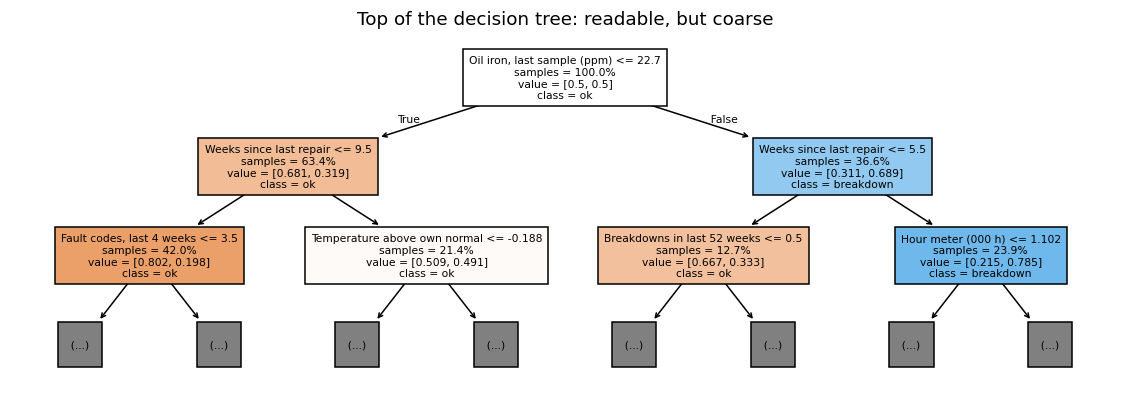

In [10]:
# The SVM outputs a distance from the boundary, not a probability. Platt scaling on the validation months turns it into one.
svm = models['SVM (RBF kernel)']
platt = LogisticRegression(C=1e6).fit(svm.decision_function(X[va]).reshape(-1, 1), y[va])
PLATT_A, PLATT_B = float(platt.coef_[0, 0]), float(platt.intercept_[0])
def proba(name, Z):
    m = models[name]
    if name == 'SVM (RBF kernel)': return 1 / (1 + np.exp(-(PLATT_A * m.decision_function(Z) + PLATT_B)))
    return m.predict_proba(Z)[:, 1]
fig, ax = plt.subplots(figsize=(13, 4.2))
plot_tree(models['Decision Tree'][-1], feature_names=[FEATURE_LABELS[f] for f in FEATS], class_names=['ok', 'breakdown'], max_depth=2, filled=True, impurity=False, proportion=True, fontsize=7, ax=ax)
ax.set_title('Top of the decision tree: readable, but coarse'); plt.show()

## 8. Compare on unseen months (test: Apr to Aug 2026)

In [11]:
P = {n: proba(n, X[te]) for n in models}
yt = y[te].values
res = pd.DataFrame({n: {'ROC-AUC': roc_auc_score(yt, p), 'PR-AUC': average_precision_score(yt, p), 'Brier score': brier_score_loss(yt, p),
                        'Recall at 50% precision': max([r for pr, r in zip(*precision_recall_curve(yt, p)[:2]) if pr >= 0.5] or [0])} for n, p in P.items()}).T
res.loc['OEM alarm limits', ['PR-AUC', 'Recall at 50% precision']] = [np.nan, base.loc['OEM alarm limits', 'recall'] if base.loc['OEM alarm limits', 'precision'] >= .5 else 0]
res = res.sort_values('PR-AUC', ascending=False); print('Test positive rate (a random guess scores this PR-AUC):', round(yt.mean(), 3)); res.round(3)

Test positive rate (a random guess scores this PR-AUC): 0.18


,ROC-AUC,PR-AUC,Brier score,Recall at 50% precision
XGBoost,0.838,0.582,0.104,0.751
Random Forest,0.862,0.577,0.108,0.728
Neural Network (MLP),0.823,0.531,0.121,0.646
SVM (RBF kernel),0.820,0.514,0.118,0.693
Logistic Regression,0.831,0.486,0.193,0.615
K-Nearest Neighbours,0.800,0.446,0.121,0.475
Decision Tree,0.760,0.397,0.207,0.195
OEM alarm limits,NaN,NaN,NaN,0.000


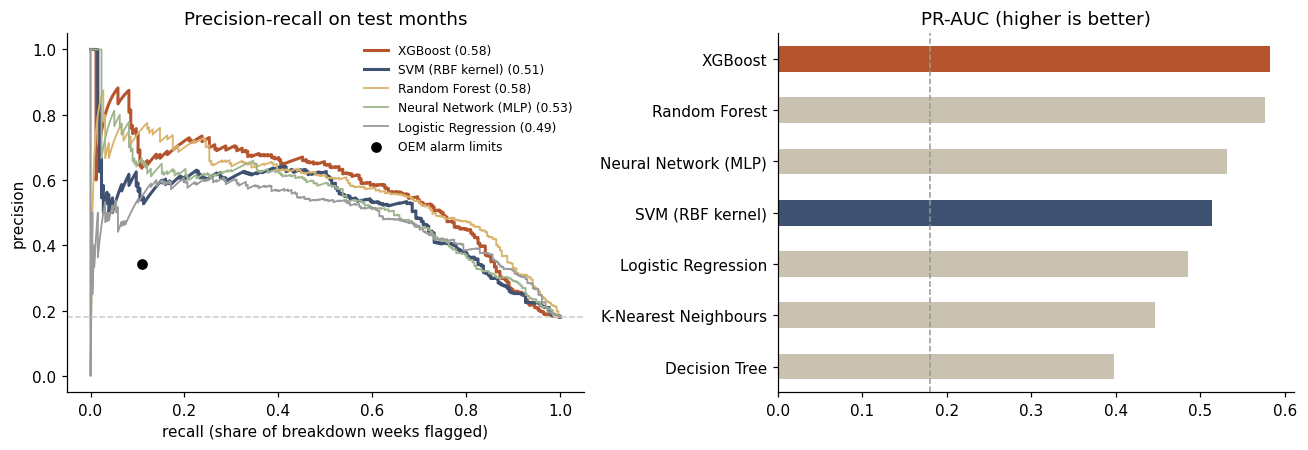

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
cols = {'XGBoost': '#b4552e', 'SVM (RBF kernel)': '#3f5170', 'Random Forest': '#d9b36b', 'Neural Network (MLP)': '#9fb58f', 'Logistic Regression': '#9a9a9a'}
for n, c in cols.items():
    pr, rc, _ = precision_recall_curve(yt, P[n]); ax[0].plot(rc, pr, color=c, lw=2 if n in ('XGBoost', 'SVM (RBF kernel)') else 1.2, label=f"{n} ({res.loc[n, 'PR-AUC']:.2f})")
b = base.loc['OEM alarm limits']; ax[0].scatter([b.recall], [b.precision], color='k', zorder=5, label='OEM alarm limits')
ax[0].axhline(yt.mean(), color='#ccc', ls='--', lw=1); ax[0].set_xlabel('recall (share of breakdown weeks flagged)'); ax[0].set_ylabel('precision'); ax[0].legend(frameon=False, fontsize=8); ax[0].set_title('Precision-recall on test months')
res['PR-AUC'].dropna().sort_values().plot.barh(ax=ax[1], color=['#b4552e' if i == 'XGBoost' else '#3f5170' if i.startswith('SVM') else '#c9c2b1' for i in res['PR-AUC'].dropna().sort_values().index])
ax[1].axvline(yt.mean(), color='#999', ls='--', lw=1); ax[1].set_title('PR-AUC (higher is better)'); plt.tight_layout(); plt.show()

## 9. XGBoost vs SVM

In [13]:
fm = ev2[ev2.event_type == 'Breakdown'][['asset_id', 'week_start', 'failure_mode']]
T = S[te].copy(); T['p_xgb'] = P['XGBoost']; T['p_svm'] = P['SVM (RBF kernel)']
T = T.merge(fm.rename(columns={'week_start': 'next_breakdown', 'failure_mode': 'next_mode'}), on=['asset_id', 'next_breakdown'], how='left')
pos = T[T.y == 1]
cmp_mode = pos.groupby('next_mode').apply(lambda g: pd.Series({'weeks': len(g), 'XGBoost mean risk': g.p_xgb.mean(), 'SVM mean risk': g.p_svm.mean()}))
cmp_mode.loc['(no breakdown ahead)'] = [int((T.y == 0).sum()), T[T.y == 0].p_xgb.mean(), T[T.y == 0].p_svm.mean()]
import time
t0 = time.time(); xgb.XGBClassifier(**models['XGBoost'].get_params()).fit(X[tr], y[tr]); tx = time.time() - t0
t0 = time.time(); make_pipeline(*prep(), SVC(**models['SVM (RBF kernel)'][-1].get_params())).fit(X[tr], y[tr]); ts = time.time() - t0
print(f"Training time: XGBoost {tx:.2f}s, SVM {ts:.2f}s | SVM support vectors: {models['SVM (RBF kernel)'][-1].n_support_.sum():,} of {tr.sum():,} training rows")
cmp_mode.round(3)

Training time: XGBoost 0.24s, SVM 0.22s | SVM support vectors: 1,285 of 3,006 training rows


,weeks,XGBoost mean risk,SVM mean risk
next_mode,,,
Bearing / gear wear,72.0,0.570,0.324
Cooling / overheating,65.0,0.533,0.301
Electrical / control fault,45.0,0.482,0.280
Hydraulic leak / pump wear,49.0,0.521,0.275
Sudden / external damage,26.0,0.112,0.129
(no breakdown ahead),1171.0,0.121,0.117


**Why the tree models (XGBoost, Random Forest) beat the SVM on this data:**
- **Missing and not-applicable values.** Hydraulic pressure is blank for a third of the fleet, and oil results arrive monthly. XGBoost learns a default direction for missing values. The SVM needs them filled first, and a filled median looks like a real reading.
- **Interactions.** A 5 °C rise matters for an electric hoist but not for an excavator in May in Nagpur. Trees split on class and condition together; an RBF kernel treats every feature as one distance.
- **Scale and outliers.** The SVM depends on scaling, and a few extreme oil-iron readings stretch the distance space. Trees only care about order.
- **Cost of the SVM.** It keeps a large share of training rows as support vectors, so training and scoring grow quickly with data. XGBoost stays fast as the fleet grows.

**Where the SVM holds up:** it still ranks risk far better than the alarm limits, gives smooth decision boundaries, and is less prone to memorising single machines. With few features and clean, complete data, the gap would narrow.

Both models give sudden external damage a low score, as expected. That is the honest limit of any sensor-based model.

## 10. Business value
A risk score is only useful if it turns into better maintenance decisions. The cost model below uses the workbook's own figures:
- **Missed breakdown:** the actual repair cost plus replacement hire for the actual downtime.
- **Caught breakdown** (an alert in any of the 4 weeks before it): a planned repair at 35% of the breakdown repair cost, plus 1 day of hire.
- **Every alert week:** an inspection costing Rs 6,000 (mechanic visit, oil sample, thermal check) plus half a day of replacement hire, because the machine stops for the check. This is conservative: in practice one inspection would cover several alert weeks.

The alert threshold is chosen on the **validation** months to minimise total cost, then applied unchanged to the test months.

In [14]:
INSPECT, PLANNED_SHARE = 6000, 0.35
HIRE = meta.set_index('asset_id').hire_in_rate_inr_per_day
def evaluate(D, p, thr):
    D = D.assign(alert=(p >= thr).astype(int))
    lo, hi = D.week_start.min() + pd.Timedelta(weeks=1), D.week_start.max() + pd.Timedelta(weeks=4)
    fails = bd[(bd.week_start >= lo) & (bd.week_start <= hi)]
    caught, lead = [], []
    al = D[D.alert == 1].groupby('asset_id').week_start.apply(set).to_dict()
    for f in fails.itertuples():
        w = [f.week_start - pd.Timedelta(weeks=k) for k in range(1, 5)]
        hit = [k for k, ww in zip(range(1, 5), w) if ww in al.get(f.asset_id, set())]
        caught.append(bool(hit)); lead.append(max(hit) if hit else 0)
    fails = fails.assign(caught=caught, lead_weeks=lead)
    run_to_fail = fails.total_cost.sum()
    cost = fails[~fails.caught].total_cost.sum() + (fails[fails.caught].cost_inr * PLANNED_SHARE + fails[fails.caught].hire_in_rate_inr_per_day).sum() + (D.alert * (INSPECT + 0.5 * D.asset_id.map(HIRE))).sum()
    return dict(breakdowns=len(fails), caught=int(fails.caught.sum()), catch_rate=fails.caught.mean(), alert_weeks=int(D.alert.sum()), median_lead_weeks=float(np.median([l for l in lead if l] or [0])),
                cost=cost, run_to_failure=run_to_fail, saving=run_to_fail - cost), fails
Sva = S[va]
thr = {}
for n in ('XGBoost', 'SVM (RBF kernel)', 'Random Forest', 'Neural Network (MLP)', 'Logistic Regression'):
    pv = proba(n, X[va]); cand = np.round(np.arange(0.05, 0.91, 0.01), 2)
    thr[n] = float(cand[np.argmin([evaluate(Sva, pv, c)[0]['cost'] for c in cand])])
print('Cost-optimal thresholds from validation:', thr)
Ste = S[te]; rows = {}; FAILS = {}
for n, th in thr.items(): rows[n], FAILS[n] = evaluate(Ste, P[n], th)
rows['OEM alarm limits'], FAILS['OEM alarm limits'] = evaluate(Ste, rule_alarm(Ste).astype(float), 0.5)
rows['PM overdue rule'], _ = evaluate(Ste, rule_pm(Ste).astype(float), 0.5)
val = pd.DataFrame(rows).T; val['saving_%'] = val.saving / val.run_to_failure * 100
v = val[['breakdowns', 'caught', 'catch_rate', 'median_lead_weeks', 'alert_weeks', 'cost', 'saving', 'saving_%']].copy()
v[['cost', 'saving']] = (v[['cost', 'saving']] / 1e5).round(1); v = v.rename(columns={'cost': 'cost_Rs_lakh', 'saving': 'saving_vs_run_to_failure_Rs_lakh'})
print(f"Test window: run-to-failure cost Rs {val.run_to_failure.iloc[0]/1e5:.1f} lakh for {int(val.breakdowns.iloc[0])} breakdowns"); v.sort_values('saving_%', ascending=False).round(3)

Cost-optimal thresholds from validation: {'XGBoost': 0.16, 'SVM (RBF kernel)': 0.19, 'Random Forest': 0.31, 'Neural Network (MLP)': 0.21, 'Logistic Regression': 0.57}
Test window: run-to-failure cost Rs 422.0 lakh for 82 breakdowns


,breakdowns,caught,catch_rate,median_lead_weeks,alert_weeks,cost_Rs_lakh,saving_vs_run_to_failure_Rs_lakh,saving_%
Random Forest,82.0,72.0,0.878,4.0,405.0,199.8,222.2,52.653
XGBoost,82.0,69.0,0.841,4.0,442.0,211.7,210.3,49.837
Neural Network (MLP),82.0,65.0,0.793,3.0,325.0,212.1,209.8,49.726
SVM (RBF kernel),82.0,66.0,0.805,3.0,321.0,215.8,206.2,48.858
Logistic Regression,82.0,72.0,0.878,4.0,483.0,224.9,197.1,46.704
OEM alarm limits,82.0,13.0,0.159,2.0,82.0,404.1,17.8,4.226
PM overdue rule,82.0,5.0,0.061,4.0,55.0,410.1,11.9,2.811


In [15]:
fx = FAILS['XGBoost']; fs = FAILS['SVM (RBF kernel)']
by_mode = pd.DataFrame({'breakdowns': fx.groupby('failure_mode').size(), 'XGBoost caught': fx.groupby('failure_mode').caught.mean(), 'SVM caught': fs.groupby('failure_mode').caught.mean(),
                        'OEM alarms caught': FAILS['OEM alarm limits'].groupby('failure_mode').caught.mean()}).round(2)
by_mode

,breakdowns,XGBoost caught,SVM caught,OEM alarms caught
failure_mode,,,,
Bearing / gear wear,24,1.00,0.96,0.00
Cooling / overheating,20,0.95,0.80,0.05
Electrical / control fault,13,0.85,0.85,0.85
Hydraulic leak / pump wear,15,0.87,0.80,0.00
Sudden / external damage,10,0.20,0.40,0.10


Every ML model catches most wear-related breakdowns with one to four weeks' warning, while the absolute alarm limits catch very few, and late. XGBoost and Random Forest are close on cost; the differences between the top models are within what a different five-month window could change, so the choice between them should rest on ranking quality (PR-AUC), explainability and ease of running. Sudden damage stays mostly uncaught by every method, as expected. These savings come from five months of one synthetic fleet, so treat the rupee figures as an illustration of the method rather than a promise.

**When the workshop has limited capacity.** A cost-optimal threshold can raise more alerts than one mechanic team can handle. A more practical rule is: each week, inspect the *K* machines with the highest risk. This compares the models on that basis.

In [16]:
def top_k(D, p, k):
    D = D.assign(p=p); flag = D.groupby('week_start').p.rank(ascending=False, method='first') <= k
    return evaluate(D.assign(p=flag.astype(float)), flag.astype(float).values, 0.5)[0]
cap = pd.DataFrame({f'top {k} per week': {n: top_k(Ste, P[n], k)['catch_rate'] for n in ('XGBoost', 'Random Forest', 'SVM (RBF kernel)', 'Neural Network (MLP)', 'Logistic Regression')} for k in (5, 10, 15)})
cap.loc['Random choice (expected)'] = [min(1, 1 - (1 - k / Ste.groupby('week_start').size().mean()) ** 4) for k in (5, 10, 15)]
print('Share of test-period breakdowns caught when only K machines can be inspected each week'); cap.round(3)

Share of test-period breakdowns caught when only K machines can be inspected each week


,top 5 per week,top 10 per week,top 15 per week
XGBoost,0.512,0.707,0.793
Random Forest,0.476,0.659,0.805
SVM (RBF kernel),0.390,0.598,0.732
Neural Network (MLP),0.427,0.646,0.756
Logistic Regression,0.366,0.573,0.756
Random choice (expected),0.263,0.471,0.631


## 11. Explain the model (SHAP)

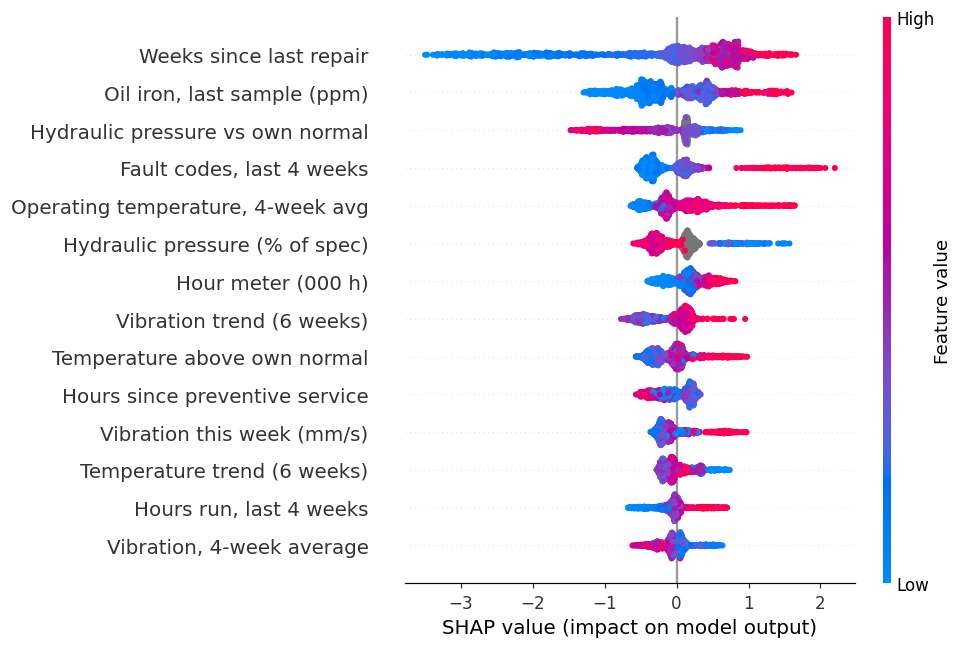

Weeks since last repair              0.893
Oil iron, last sample (ppm)          0.500
Hydraulic pressure vs own normal     0.384
Fault codes, last 4 weeks            0.344
Operating temperature, 4-week avg    0.309
Hydraulic pressure (% of spec)       0.278
Hour meter (000 h)                   0.252
Vibration trend (6 weeks)            0.232
Temperature above own normal         0.209
Hours since preventive service       0.203
dtype: float32

In [17]:
xm = models['XGBoost']
explainer = shap.TreeExplainer(xm)
sv = explainer.shap_values(X[te])
shap.summary_plot(sv, X[te].rename(columns=FEATURE_LABELS), max_display=14, show=False, plot_size=(9, 6)); plt.tight_layout(); plt.show()
imp = pd.Series(np.abs(sv).mean(0), index=FEATS).sort_values(ascending=False)
imp.head(10).rename(FEATURE_LABELS).round(3)

The model relies on the same signals a plant engineer would check: oil iron, temperature and vibration **compared with the machine's own normal**, hydraulic pressure drop, fault codes, and time since the last repair. Machine class matters mainly through interactions, not as a standalone penalty.

## 12. This week's maintenance worklist

In [18]:
L = d[d.week_start == LIVE_WEEK].copy()
Lop = L[L.status == 'Operating'].copy()
Lop['risk_xgb'] = proba('XGBoost', Lop[FEATS]); Lop['risk_svm'] = proba('SVM (RBF kernel)', Lop[FEATS])
svl = explainer.shap_values(Lop[FEATS])
Lop['drivers'] = [[(FEATURE_LABELS[FEATS[j]], float(round(v, 3))) for j, v in sorted(enumerate(r), key=lambda z: -z[1])[:3] if v > 0] for r in svl]
Lop['alert'] = Lop.risk_xgb >= thr['XGBoost']
wl = Lop.sort_values('risk_xgb', ascending=False)[['asset_id', 'asset_class', 'project_id', 'city', 'risk_xgb', 'risk_svm', 'alert', 'drivers']]
print(f"Week of {LIVE_WEEK.date()}: {len(Lop)} machines operating, {int(Lop.alert.sum())} above the XGBoost alert threshold ({thr['XGBoost']:.2f}); {int((L.status != 'Operating').sum())} not operating")
wl.head(12).assign(drivers=lambda z: z.drivers.map(lambda r: '; '.join(a for a, _ in r))).round(3)

Week of 2026-09-21: 78 machines operating, 32 above the XGBoost alert threshold (0.16); 2 not operating


,asset_id,asset_class,project_id,city,risk_xgb,risk_svm,alert,drivers
4208,AST0065,Concrete Pump,NaN,Noida,0.904,0.262,True,"Oil iron, last sample (ppm); Weeks since last ..."
4867,AST0076,Transit Mixer,NaN,Kolkata,0.881,0.101,True,Weeks since last repair; Hydraulic pressure (%...
640,AST0008,Passenger Hoist,NaN,Jaipur,0.860,0.287,True,Weeks since last repair; Hour meter (000 h); T...
5263,AST0083,Excavator,NaN,Noida,0.790,0.418,True,"Operating temperature, 4-week avg; Weeks since..."
2809,AST0044,Backhoe Loader,NaN,Hyderabad,0.778,0.312,True,"Operating temperature, 4-week avg; Weeks since..."
2901,AST0045,Concrete Pump,NaN,Surat,0.738,0.189,True,"Operating temperature, 4-week avg; Weeks since..."
4437,AST0068,Passenger Hoist,NaN,Noida,0.706,0.471,True,"Fault codes, last 4 weeks; Weeks since last re..."
4800,AST0075,Concrete Pump,NaN,Nagpur,0.645,0.515,True,Hydraulic pressure (% of spec); Hydraulic pres...
1281,AST0021,Tower Crane,NaN,Gurugram,0.638,0.249,True,"Oil iron, last sample (ppm); Weeks since last ..."
2275,AST0035,Concrete Pump,NaN,Delhi,0.635,0.323,True,Hydraulic pressure (% of spec); Weeks since la...


## 13. Export for the web app
The browser app runs the same XGBoost trees and the same SVM (support vectors, kernel, Platt scaling) so a user can change sensor values and watch both risk scores move.

In [19]:
def dump(m): return [json.loads(tr_) for tr_ in m.get_booster().get_dump(dump_format='json')]
def base_margin(m):
    bs = float(json.loads(m.get_booster().save_config())['learner']['learner_model_param']['base_score'].strip('[]'))
    return float(np.log(bs / (1 - bs)))
imp_s, sc_s, svc = svm[0], svm[1], svm[-1]
gamma = svc._gamma
fnum = lambda v: None if pd.isna(v) else round(float(v), 4)
fx6 = lambda v: None if pd.isna(v) else float(np.float32(v))
hist = d[d.status != 'Not monitored'].copy()
hist_op = hist.status == 'Operating'
hist['p_xgb'] = np.nan; hist.loc[hist_op, 'p_xgb'] = proba('XGBoost', hist.loc[hist_op, FEATS])
series = {}
for a, g in hist.groupby('asset_id'):
    series[a] = {'w': g.week_start.dt.strftime('%Y-%m-%d').tolist(), 's': g.status.str[0].tolist(),
                 'vib': [fnum(v) for v in g.vib_4w], 'temp': [fnum(v) for v in g.temp_4w], 'prs': [fnum(v) for v in g.pressure_4w], 'iron': [fnum(v) for v in g.iron_last],
                 'flt': [fnum(v) for v in g.faults_4w], 'p': [fnum(v) for v in g.p_xgb]}
bd_list = bd[['asset_id', 'week_start', 'failure_mode', 'downtime_days', 'cost_inr', 'hire_in_rate_inr_per_day', 'total_cost']].assign(week_start=lambda z: z.week_start.dt.strftime('%Y-%m-%d')).to_dict(orient='records')
export = {
  'features': FEATS, 'labels': FEATURE_LABELS, 'live_week': str(LIVE_WEEK.date()),
  'xgb': {'base_margin': base_margin(xm), 'trees': dump(xm)},
  'svm': {'medians': [float(v) for v in imp_s.statistics_], 'mean': sc_s.mean_.tolist(), 'scale': sc_s.scale_.tolist(), 'gamma': float(gamma),
          'sv': np.round(svc.support_vectors_, 6).tolist(), 'coef': np.round(svc.dual_coef_[0], 8).tolist(), 'intercept': float(svc.intercept_[0]), 'platt': [PLATT_A, PLATT_B]},
  'threshold': thr, 'inspect_cost': INSPECT, 'planned_share': PLANNED_SHARE,
  'results': res.reset_index().rename(columns={'index': 'model'}).replace({np.nan: None}).to_dict(orient='records'),
  'value': val.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'), 'by_mode': by_mode.reset_index().rename(columns={'index': 'failure_mode'}).to_dict(orient='records'),
  'importance': imp.head(12).round(4).to_dict(), 'capacity': cap.reset_index().rename(columns={'index': 'model'}).to_dict(orient='records'),
  'test': {'asset': Ste.asset_id.tolist(), 'week': Ste.week_start.dt.strftime('%Y-%m-%d').tolist(), 'y': yt.tolist(),
           'p_xgb': np.round(P['XGBoost'], 5).tolist(), 'p_svm': np.round(P['SVM (RBF kernel)'], 5).tolist()},
  'breakdowns': bd_list,
  'meta': meta.assign(telematics_since=meta.telematics_since.astype(str)).to_dict(orient='records'), 'fleet': {r.asset_id: r.asset_name for r in asset.itertuples()},
  'live': [dict(asset_id=r.asset_id, status=r.status, project_id=None if pd.isna(r.project_id) else r.project_id, city=r.city,
                x=[fx6(r[f]) for f in FEATS] if r.status == 'Operating' else None) for _, r in L.iterrows()],
  'live_py': {r.asset_id: [round(r.risk_xgb, 6), round(r.risk_svm, 6), r.drivers] for r in Lop.itertuples()},
  'series': series,
  'check': [dict(x=[fx6(v) for v in X[te].iloc[i]], xgb=float(P['XGBoost'][i]), svm=float(P['SVM (RBF kernel)'][i])) for i in range(0, te.sum(), 9)],
  'split': summary.reset_index().assign(first_week=lambda z: z.first_week.astype(str), last_week=lambda z: z.last_week.astype(str)).to_dict(orient='records'),
  'n_breakdowns': int(len(bd)), 'breakdown_cost': float(bd.total_cost.sum()), 'n_support': int(svc.n_support_.sum()), 'n_train': int(tr.sum()),
}
with open('../model/pdm_export.json', 'w') as f: json.dump(export, f, separators=(',', ':'), allow_nan=False)
import os; print('Exported', len(export['xgb']['trees']), 'XGBoost trees,', len(export['svm']['sv']), 'support vectors,', f"{os.path.getsize('../model/pdm_export.json')/1e6:.2f} MB")

Exported 400 XGBoost trees, 1285 support vectors, 1.38 MB


## Summary
- **Data:** 80 telematics-fitted machines from the existing asset register, 103 weeks of readings, 249 breakdowns costing Rs 12.1 crore in repairs and replacement hire. Missing values are handled by cause: dropouts, not-applicable sensors and monthly oil samples.
- **Method:** a 4-week-ahead breakdown label, leakage-safe features relative to each machine's own normal, a time-based train/validation/test split, two rule baselines, and seven ML models tuned on validation months.
- **Result:** XGBoost has the best ranking quality (PR-AUC, section 8), with Random Forest close behind. At a cost-optimal threshold the ML models catch most wear-related breakdowns weeks ahead and roughly halve breakdown cost in the test months (section 10). The SVM is a solid second tier: far better than the alarm limits, but below the tree ensembles on this sparse, mixed-type data.
- **Explainability:** SHAP drivers match engineering logic, and each alert in the worklist lists its top three reasons.
- **Honest limits:** the telemetry is synthetic with known wear physics, so real fleets will be noisier. Sudden damage cannot be predicted. The model should be retrained quarterly and checked against real breakdown reports, and the rupee savings depend on the inspection and planned-repair cost assumptions.